Slope without COVID:  0.04571428571428573
Slope with Covid:  0.056617647058823675

Big O for Cubic Spline Interpolation: O(n^2)
Big O for Linear Least Squares: O(n)
Big O for Polynomial fit of Degree 4: O(n)


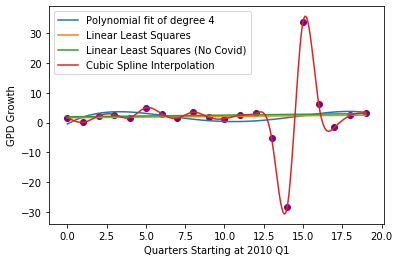

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  
    A = np.zeros(n - 2) 
    B = np.zeros(n - 2)  
    C = np.zeros(n - 2)  
    D = np.zeros(n - 2)  

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]                                                          
        B[i - 1] = 2*(h[i-1]+h[i])                                                
        C[i - 1] = h[i]                                                           
        D[i - 1] = 6 * (((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))            

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, xval):
    for i in range(len(x) - 1):
        if x[i] <= xval <= x[i+1]:
            h = x[i+1] - x[i]
            first = M[i] / (6*h) * ((x[i+1] - xval)**3)
            second = M[i+1] / (6*h) * ((xval - x[i])**3)
            third = ((y[i] / h) - ((M[i] * h / 6))) * (x[i+1] - xval)
            fourth = ((y[i+1] / h) - ((M[i+1] * h / 6))) * (xval - x[i])
            
            S = first + second + third + fourth
            return S

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
x = np.arange(len(y))
x_full = np.linspace(x[0], x[-1], 300)

A, B, C, D = setup_tridiagonal_matrix(x, y)
D2 = thomas_algorithm(A, B, C, D)

M= np.zeros(len(x))
M[1:-1] = D2

yvals= []
for j in x_full: 
    yvals.append(evaluate_spline(x ,y ,M ,j))

x_no_covid = np.delete(x, np.arange(13, 18))
y_no_covid = np.delete(y, np.arange(13, 18))

B = np.vstack([x_no_covid, np.ones(len(x_no_covid))]).T
m_no_covid, C, = np.linalg.lstsq(B, y_no_covid, rcond=None)[0]

A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
print('Slope without COVID: ', m)
print('Slope with Covid: ', m_no_covid)


degree = 4
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x_full)

print('')
print('Big O for Cubic Spline Interpolation: O(n^2)')
print('Big O for Linear Least Squares: O(n)')
print('Big O for Polynomial fit of Degree 4: O(n)')

plt.plot(x_full, y_pred, label=f'Polynomial fit of degree 4')
plt.plot(x_full, m*x_full +c, label = 'Linear Least Squares')
plt.plot(x_full, m_no_covid*x_full +C, label = 'Linear Least Squares (No Covid)')
plt.plot(x_full, yvals, label = 'Cubic Spline Interpolation')
plt.scatter(x,y, color = 'purple')
plt.xlabel('Quarters Starting at 2010 Q1')
plt.ylabel('GPD Growth')
plt.legend()
plt.show()